## Exercise 1: Polynomial Regression

Generate a regression dataset:

- **X generation:** `X = (2 - 3*np.random.normal(0,1,200)).reshape(200,1)`
- **y generation:** `y = 0.5*X^3 - 2*X^2 + X + np.random.normal(-3,3,200).reshape(-1,1)`

Apply a polynomial regression algorithm and plot the predictions of the model for a test set `X_test = np.linspace(-5, 10, 200).reshape(200, 1)`.


In [9]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

X = (2 - 3 * np.random.normal(0, 1, 200)).reshape(200, 1)
y = 0.5 * X**3 - 2 * X**2 + X + np.random.normal(-3, 3, 200).reshape(-1, 1)
X_test = np.linspace(-5, 10, 200).reshape(200, 1)

poly_features = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly_features.fit_transform(X)

lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
print(lin_reg.intercept_, lin_reg.coef_)

[-2.92124548] [[ 1.02600991 -2.02058489  0.50316819]]


In [10]:
X_test = np.linspace(-5, 10, 200).reshape(200, 1)
X_test_poly = poly_features.transform(X_test)
y_test = lin_reg.predict(X_test_poly)

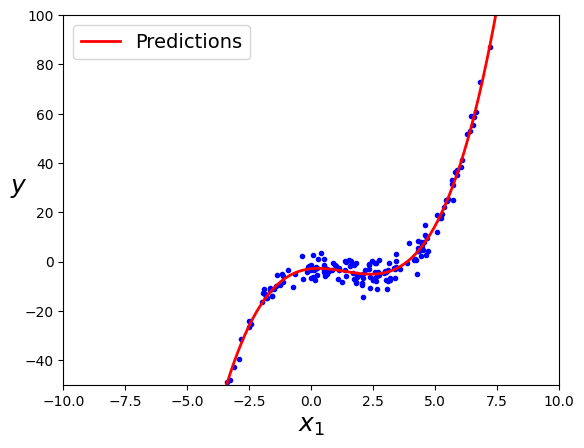

In [11]:
plt.plot(X, y, "b.")
plt.plot(X_test, y_test, "r-", linewidth=2, label="Predictions")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.legend(loc="upper left", fontsize=14)
plt.axis([-10, 10, -50, 100])
plt.show()

## Exercise 2: Ridge Regression with Mini-Batch Gradient Descent

Generate a regression dataset:

- **X generation:** `X = 3*np.random.rand(150,1)`
- **y generation:** `y = -2 + 3*X + np.random.randn(150, 1)`

Perform ridge regression using mini-batch gradient descent with the following parameters:

- Learning rate: 0.06
- Epochs: 15
- Batch size: 10
- Lambda (λ): 0.01

Plot the prediction of the model and print the model weights.


In [12]:
learning_rate = 0.06
epochs = 15
batch_size = 10
alpha = 0.01
data_points = 150

X = 3 * np.random.rand(data_points, 1)
y = -2 + 3 * X + np.random.randn(data_points, 1)

weights = np.random.randn(2, 1)
X_1 = np.c_[np.ones((data_points, 1)), X]

for epoch in range(epochs):
    shuffled_indices = np.random.permutation(data_points)
    X_1_shuffled = X_1[shuffled_indices]
    y_shuffled = y[shuffled_indices]
    for i in range(0, data_points, batch_size):
        xi = X_1_shuffled[i : i + batch_size]
        yi = y_shuffled[i : i + batch_size]
        gradients = 1 / batch_size * xi.T.dot(xi.dot(weights) - yi) + alpha * weights
        weights -= learning_rate * gradients

print("weights:", weights)

weights: [[-1.64809066]
 [ 2.73216154]]


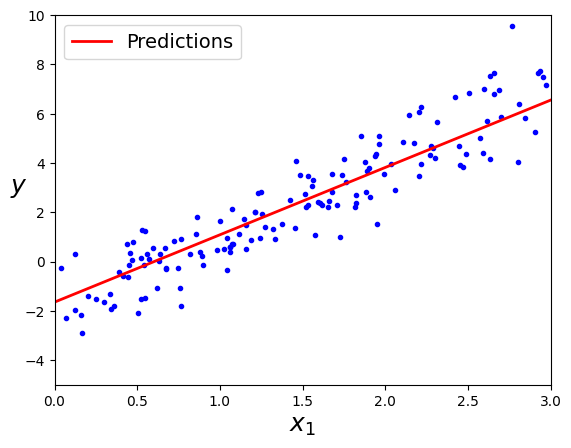

In [13]:
X_test = np.linspace(0, 3, data_points).reshape(data_points, 1)
X_test_1 = np.c_[np.ones((data_points, 1)), X_test]
y_test = X_test_1.dot(weights)

plt.plot(X, y, "b.")
plt.plot(X_test, y_test, "r-", linewidth=2, label="Predictions")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.legend(loc="upper left", fontsize=14)
plt.axis([0, 3, -5, 10])
plt.show()

## Exercise 3: Softmax Regression on Digits Dataset

Apply the softmax regression algorithm using the `digits` dataset.

- **Dataset loading:** Call the `load_digits` function.
- **Data splitting:** Split the data such that the test set comprises 35% of the initial dataset.
- **Initial output:** Print the shapes of the training and testing datasets.
- **Algorithm training:** Train the algorithm for 700 epochs, using the "lbfgs" solver, and set the hyperparameter `C` to 5.
- **Post-training output:** After the model is trained, print the test set accuracy. Additionally, predict and print the probabilities that the model assigned to the ten classes for the second example in the test set.


In [14]:
from string import digits
from sklearn.linear_model import LogisticRegression
from sklearn import datasets
from sklearn.model_selection import train_test_split

digits_dataset = datasets.load_digits()

X_train, X_test, y_train, y_test = train_test_split(
    digits_dataset["data"], digits_dataset["target"], test_size=0.35, random_state=0
)
softmax_reg = LogisticRegression(max_iter=700, solver="lbfgs", C=5, random_state=42)

softmax_reg.fit(X_train, y_train)
softmax_reg.score(X_test, y_test)

0.9523052464228935